**Exercício 3**

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

Letra a)

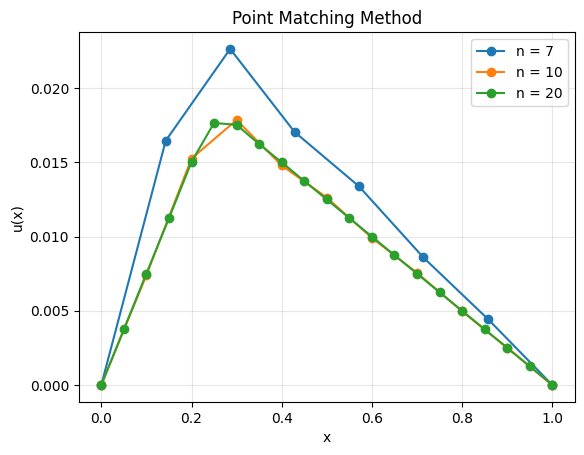

In [109]:
n = [7,10,20]
da = 0 
db = 1
xa = 0.2
xb = 0.3

def f(xm,xa,xb):
    if (xm <= xb) & (xm >= xa): return 1
    else: return 0

plt.figure()
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('u(x)')

U = []

for j in range(3):
    delta = (db-da)/n[j]
    x = np.linspace(da,db,n[j]+1)
    xm = np.linspace(da+delta/2, db-delta/2, n[j])
    A = np.zeros((n[j],n[j]))
    b = np.zeros(n[j])

    for i in range(n[j]):
        b[i] = f(xm[i],xa,xb)
        for k in range(n[j]):
            A[i,k] = ((k + 1) * np.pi)**2 * np.sin((k + 1) * np.pi * xm[i])

    alpha = np.linalg.solve(A,b)

    u = np.zeros(n[j]+1)
    for i in range(1,n[j]+1):
        u[i] = np.sum(alpha * np.sin(np.arange(1,n[j]+1)* np.pi *x[i]))

    plt.plot(x,u,'o',ls='-',label=f'n = {n[j]}')
    U.append(u.copy())

plt.title('Point Matching Method')
plt.legend()
plt.show()

Letra b)

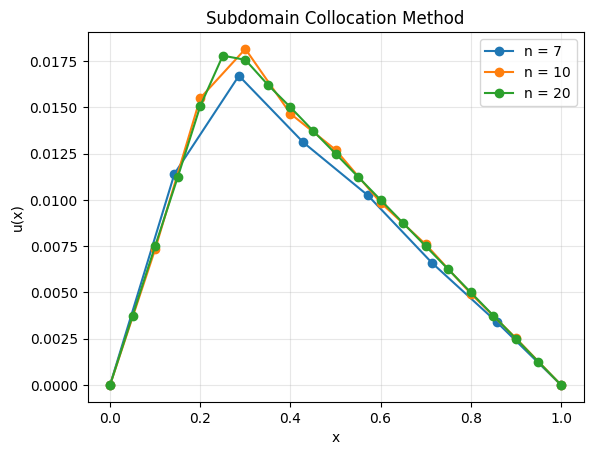

In [ ]:
plt.figure()
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('u(x)')

for j in range(3):
    delta = (db-da)/n[j]
    x = np.linspace(da,db,n[j]+1)
    xm = np.linspace(da+delta/2, db-delta/2, n[j])
    A = np.zeros((n[j],n[j]))
    b = np.zeros(n[j])

    for i in range(n[j]):
        b[i] = quad(lambda x: f(x,xa,xb),x[i],x[i+1])[0]
        for k in range(n[j]):
            A[i,k] = (k + 1) * np.pi * (np.cos((k + 1) * np.pi * x[i]) - np.cos((k + 1) * np.pi * x[i+1]))

    alpha = np.linalg.solve(A,b)

    u = np.zeros(n[j]+1)
    for i in range(1,n[j]+1):
        u[i] = np.sum(alpha * np.sin(np.arange(1,n[j]+1)* np.pi *x[i]))

    plt.plot(x,u,'o',ls='-',label=f'n = {n[j]}')
    U.append(u.copy())

plt.title('Subdomain Collocation Method')
plt.legend()
plt.show()

Letra c)

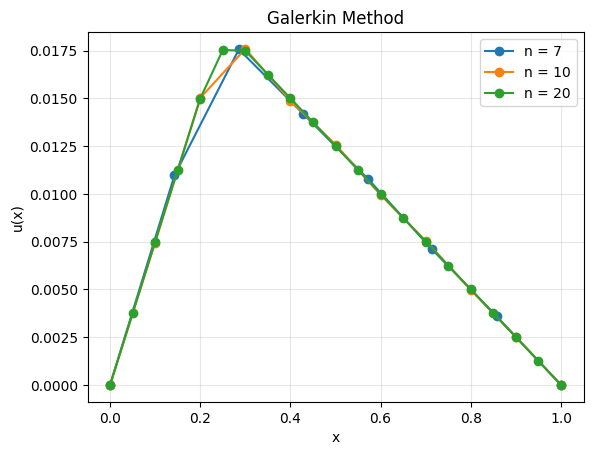

In [111]:
plt.figure()
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('u(x)')

for j in range(3):
    delta = (db-da)/n[j]
    x = np.linspace(da,db,n[j]+1)
    k = np.arange(1,n[j]+1)

    alpha = 2*(np.cos(k*np.pi*xa)-np.cos(k*np.pi*xb)) / (k*np.pi)**3

    u = np.zeros(n[j]+1)
    for i in range(1,n[j]+1):
        u[i] = np.sum(alpha * np.sin(np.arange(1,n[j]+1)* np.pi *x[i]))

    plt.plot(x,u,'o',ls='-',label=f'n = {n[j]}')
    U.append(u.copy())

plt.title('Galerkin Method')
plt.legend()
plt.show()

Letra d)

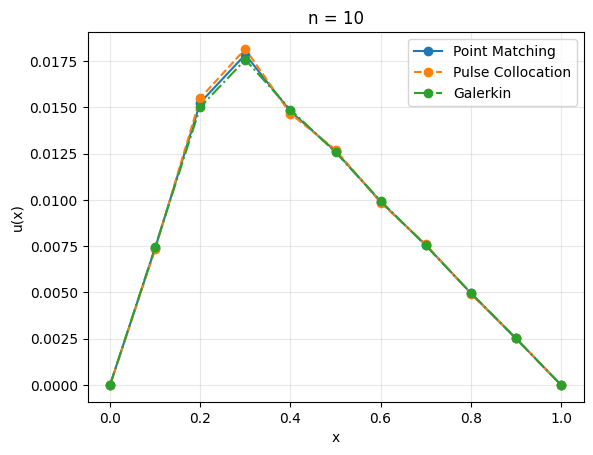

In [112]:
x = np.linspace(da,db,10+1)

plt.figure()
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.plot(x,U[1],'o',ls='-',label=f'Point Matching')
plt.plot(x,U[4],'o',ls='--',label=f'Pulse Collocation')
plt.plot(x,U[7],'o',ls='-.',label=f'Galerkin')
plt.title('n = 10')
plt.legend()
plt.show()